# 01 · Do the prices add up to $1?

**The idea in one sentence.** On Polymarket, an event like *"What will the Fed decide in October?"* has several outcomes
(cut 50, cut 25, no change, hike 25, hike 50). Exactly one of them will happen, and each "YES" share pays **$1** if its outcome happens.
So if you bought one YES share of *every* outcome you would get exactly $1 back, no matter what. That means the prices of all the
YES shares **should add up to $1.00**.

In practice they don't add up exactly, because traders are human, markets are busy and trading has costs. This notebook looks at real
Polymarket data and asks three simple questions:

1. How far from $1.00 does the total (we call it **S**) actually move?
2. When it moves away, does it come back? (*mean reversion*)
3. Is the gap ever big enough to profit from after trading costs?

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import logging; logging.getLogger("src").setLevel(logging.ERROR)  # the live recorder may be mid-write
import numpy as np, pandas as pd
from IPython.display import Markdown, display
from src import plotting as P, stats_tools as st, research as R
from src.config import load_markets, get_basket
pd.set_option("display.float_format", "{:.4f}".format)
cfg = load_markets()
BASKET = "fed-oct-2026"
ALL = ["fed-oct-2026", "balance-of-power-2026", "house-2026", "senate-2026", "mlb-ws-2026"]
basket = get_basket(BASKET, cfg)

## 1. The data

We use **real Polymarket prices**: the price of every outcome, once a minute, for the last 30 days (downloaded with
`python -m src.recorder backfill`). The price used is the *midpoint*, halfway between the best offer to buy and the best offer to sell.

In [2]:
prices, info = R.price_panel(BASKET, cfg)
display(Markdown(info.banner_markdown()))
S = prices.sum(axis=1).rename("S")
DK = info.label
display(pd.DataFrame({"outcome": [l.label for l in basket.legs],
                      "average price": prices.mean().to_numpy(),
                      "taker fee rate": [l.fee.rate for l in basket.legs]}).set_index("outcome"))

**DATA: REAL Polymarket price history** (`/prices-history`). Prices are real but not executable; wherever execution is simulated, bid/ask/depth are **MODELLED** around them.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-09-02T03:01:00 | 2026-10-02T02:59:00 | 720.0 | 43,189 | 1 |

> Execution books are MODELLED: per-leg spread 50-bps-decrease=1 tick(s), 25-bps-decrease=1 tick(s), no-change=1 tick(s), 25-bps-increase=1 tick(s), 50-bps-increase=1 tick(s) (default 1 tick).

,average price,taker fee rate
outcome,,
50+ bps decrease,0.0044,0.0500
25 bps decrease,0.0172,0.0500
No change,0.5453,0.0500
25 bps increase,0.4354,0.0500
50+ bps increase,0.0083,0.0500


## 2. The single prices move a lot; their total barely moves

The first chart shows each outcome's price. "No change" and "hike 25" swing around as news comes in. The second chart adds them all up:
the total stays in a narrow band close to $1.00. When one outcome gets more likely, the others get cheaper by about the same amount.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


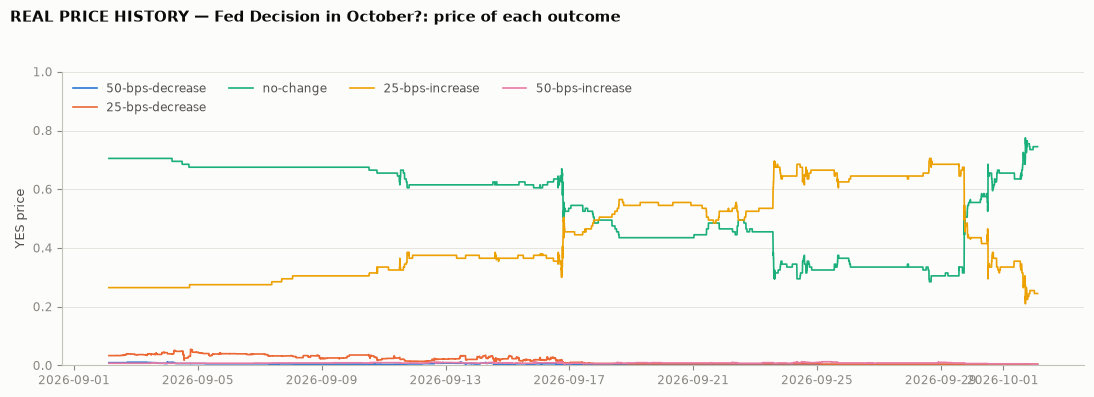

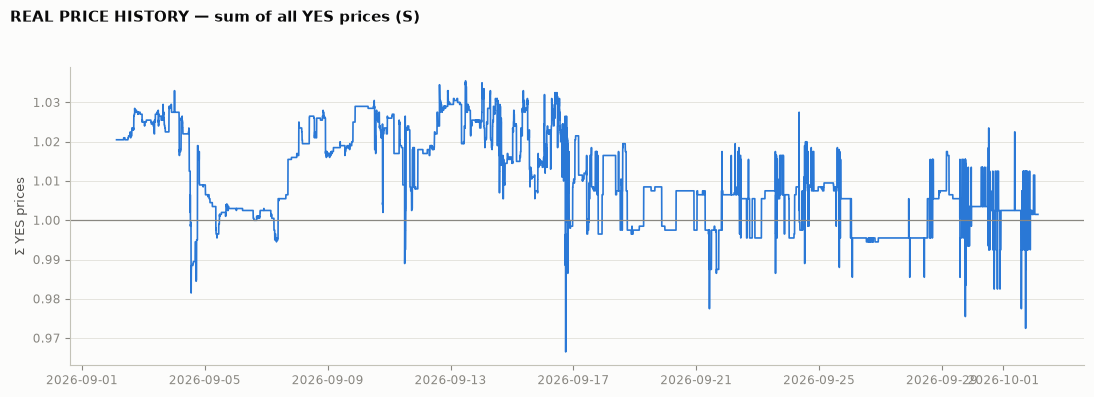

In [3]:
P.show(P.plot_legs(prices, data_kind=DK, title=f"{basket.title}: price of each outcome"), "01_legs")
P.show(P.plot_sum_band(pd.DataFrame({"s_mid": S}), data_kind=DK, title="sum of all YES prices (S)"), "01_sum_band")

* Average total: **$1.0105**, so on average the outcomes are priced about **+1.05 cents** above the fair $1.00.
* 98% of the time the total stays between **$0.990** and **$1.030**.
* The blueprint guessed it would stay between $0.96 and $1.05: true **100%** of the time.

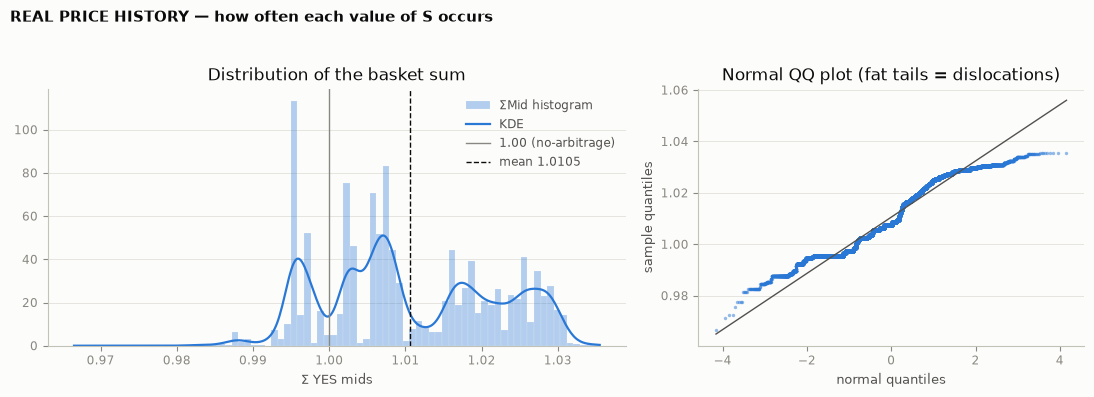

In [4]:
q01, q99 = S.quantile(0.01), S.quantile(0.99)
display(Markdown(f"* Average total: **${S.mean():.4f}**, so on average the outcomes are priced about **{(S.mean() - 1) * 100:+.2f} cents** above the fair $1.00.\n"
                 f"* 98% of the time the total stays between **${q01:.3f}** and **${q99:.3f}**.\n"
                 f"* The blueprint guessed it would stay between $0.96 and $1.05: true **{((S >= 0.96) & (S <= 1.05)).mean():.0%}** of the time."))
P.show(P.plot_sum_distribution(S, data_kind=DK, title="how often each value of S occurs"), "01_sum_distribution")

## 3. Does the total come back after it moves away? (mean reversion)

Two kinds of series are worth telling apart:

* A **random walk** has no "home". Where it goes next does not depend on where it has been, so it can drift anywhere. A single outcome's
  price looks like this: it follows the news.
* A **mean-reverting** series keeps getting pulled back towards an average. If the total really should be about $1, it should look like this.

The standard check is the **ADF test** (Augmented Dickey–Fuller). It starts from the assumption "this is a random walk" and reports a
**p-value**. A small p-value (below 0.05) means *"it is very unlikely to be a random walk"*, so the series is pulled back towards its average.

In [5]:
rows = []
for name, x in [*[(f"outcome: {l.label}", prices[l.leg_id]) for l in basket.legs if prices[l.leg_id].mean() > 0.02], ("TOTAL S", S)]:
    p = st.adf_test(x)["pvalue"]
    rows.append({"series": name, "ADF p-value": p, "verdict": "pulled back to its average" if p < 0.05 else "random walk (drifts)"})
adf = pd.DataFrame(rows).set_index("series")
display(adf)

,ADF p-value,verdict
series,,
outcome: No change,0.7227,random walk (drifts)
outcome: 25 bps increase,0.6979,random walk (drifts)
TOTAL S,0.0000,pulled back to its average


**How fast does it come back?** We measure the *half-life*: after the total jumps away from its average, how long until half of that
gap has closed. (It comes from fitting a simple "today = a × yesterday + noise" model.)

Half-life ≈ **117 minutes**: a gap in the total typically halves in about 2.0 hours.

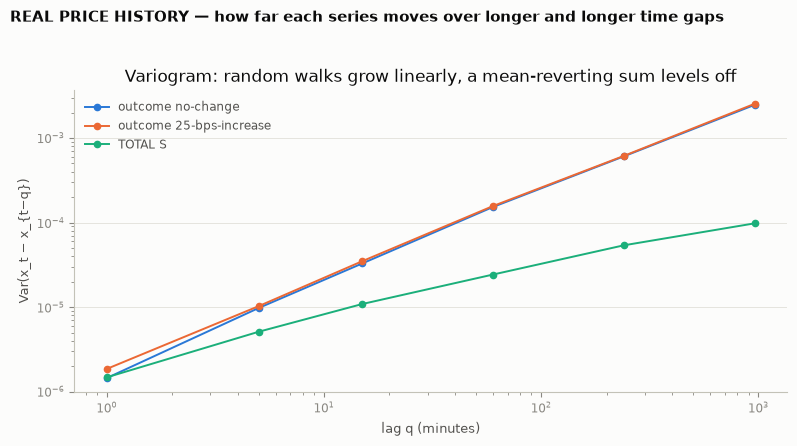

In the chart above, the single outcomes keep moving further the longer you wait (a straight line going up). The total flattens out: it does not wander off, it keeps coming back.

In [6]:
fit = st.ar1_fit(S, 60.0)
half_life_min = fit["half_life_s"] / 60
display(Markdown(f"Half-life ≈ **{half_life_min:.0f} minutes**: a gap in the total typically halves in about {half_life_min / 60:.1f} hours."))
lags = [1, 5, 15, 60, 240, 960]
big = [l.leg_id for l in basket.legs if prices[l.leg_id].mean() > 0.02]
curves = {f"outcome {c}": (lags, st.variogram(prices[c].to_numpy(), lags)) for c in big}
curves["TOTAL S"] = (lags, st.variogram(S.to_numpy(), lags))
P.show(P.plot_variogram(curves, data_kind=DK, title="how far each series moves over longer and longer time gaps"), "01_variogram")
display(Markdown("In the chart above, the single outcomes keep moving further the longer you wait (a straight line going up). "
                 "The total flattens out: it does not wander off, it keeps coming back."))

## 4. Can you trade it? The cost of a round trip

You can't buy at the midpoint. You buy at the **ask** (a bit higher) and sell at the **bid** (a bit lower), and Polymarket charges a
**taker fee** of about `rate × price × (1 − price)` per share. To trade the total you have to buy **every** outcome and later sell every
outcome, so you pay the gap between bid and ask on all of them, twice, plus fees.

The table below compares the typical size of the total's moves with that round-trip cost for five live events. If the cost is bigger than
the typical move, trading the reversion loses money.

In [7]:
h = R.hurdle_table(cfg, ALL)
simple = pd.DataFrame({"typical move of S (std)": h["sd ΣP (1-min)"], "round-trip cost": h["round-trip hurdle"],
                       "move ÷ cost": h["ECR = sd/hurdle"]})
display(simple)
books = R.book_sums(BASKET, cfg, grid="10s")
if books is not None:
    bs = R.band_stats(books[0], basket)
    display(Markdown(books[2].banner_markdown()))
    display(Markdown(R.band_sentence(books[2].hours, bs["min S_ask"], bs["max S_bid"], bs["share S_ask<1"], bs["share S_bid>1"],
                                     share_beyond_fees=bs["share S_ask<1-fees"] + bs["share S_bid>1+fees"])))

,typical move of S (std),round-trip cost,move ÷ cost
basket,,,
fed-oct-2026,0.0112,0.0753,0.1487
balance-of-power-2026,0.0136,0.0783,0.1732
house-2026,0.0055,0.0350,0.1576
senate-2026,0.0064,0.0592,0.1087
mlb-ws-2026,0.0489,0.1281,0.3818


**DATA: REAL Polymarket order books** recorded live from the CLOB market WebSocket.

| basket | from | to | hours | rows | sessions |
|---|---|---|---|---|---|
| `fed-oct-2026` (Fed Decision in October?) | 2026-10-01T22:30:10 | 2026-10-08T08:19:51 | 151.6 | 93,179 | 82 |

In 151.6 hours of recorded live order books a full YES set sold for more than $1 only 1.0% of the time (at most $1.021), and never by more than the taker fees, so there was no free money after costs.

In [8]:
row = h.loc[BASKET]
display(Markdown("### What we found\n" + "\n".join([
    f"1. **The total really does stay close to $1.** It averages ${S.mean():.4f}, slightly above $1, and 98% of the time it is within "
    f"${q01:.3f} to ${q99:.3f}.",
    f"2. **It is pulled back towards its average** (ADF p-value {R.fmt_p(adf.loc['TOTAL S', 'ADF p-value'])}), while the individual outcomes "
    f"wander. Gaps halve in about {half_life_min / 60:.1f} hours.",
    f"3. **But the moves are small compared with trading costs.** A round trip costs about ${row['round-trip hurdle']:.3f} per basket, while "
    f"the total typically moves about ${row['sd ΣP (1-min)']:.3f}. Notebook 02 tests whether a trading strategy can still make money.",
])))
_ = R.save_dataset_info("01", [info] + ([books[2]] if books is not None else []),
                    {"basket_stats": R.basket_stats_table(cfg, [BASKET]).reset_index().to_dict("records"),
                     "half_life_min": float(half_life_min), "hurdles": h.reset_index().to_dict("records")})

### What we found
1. **The total really does stay close to $1.** It averages $1.0105, slightly above $1, and 98% of the time it is within $0.990 to $1.030.
2. **It is pulled back towards its average** (ADF p-value <1e-4), while the individual outcomes wander. Gaps halve in about 2.0 hours.
3. **But the moves are small compared with trading costs.** A round trip costs about $0.075 per basket, while the total typically moves about $0.011. Notebook 02 tests whether a trading strategy can still make money.

### Caveats
* The once-a-minute prices are sampled separately for each outcome, so short spikes in the total can just be timing noise.
* This is one event over 30 days. News days (data releases, Fed speeches) can shift the average level.